# CI failure classification

**Recipe 19** · Level 2 (Easy) · Decision type: `Choice`

Classify a trimmed excerpt of a continuous-integration log as a test regression, a dependency problem, an infrastructure failure, or unknown, and use that to pick the next diagnostic workflow.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S05: [TypeSafe AI: Example use cases](https://docs.typesafe.ai/concepts/use-case-map)

## What you will build

A classifier for CI failure logs. Python trims each build's log down to the excerpt that matters *before* it ever builds a request, keeping the untrimmed log in the fixtures so the trimming below is checked against real data, not merely illustrated. Jev then reads the excerpt and picks exactly one of four outcomes: `test_regression`, `dependency_problem`, `infrastructure_failure`, or `unknown`. Python owns a fixed table that turns an outcome into the next diagnostic workflow, a simulated action that is only ever logged, never executed; it decides when an answer is confident enough to log that workflow as chosen, and sends anything else to an explicit review queue instead, except `unknown`, whose own workflow, manual triage, commits to no automated remedy and so needs no confidence gate at all. By the end you will have looked at individual typed answers across the hard cases this use case names, including one where the trimming itself decides what Jev can see, and run an evaluation that chooses its one setting on `validation` and reports on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# build that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "outcome"
        ]
    return answered[example.id]


run_header(19, "CI failure classification", backend=backend, n_examples=len(scored))

Recipe 19: CI failure classification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

Python trims each build's log down to the excerpt it actually sends to Jev, *before* it builds a request: `helpers.trim_log` keeps a one-line window around every line that names a dependency or infrastructure problem, wherever it falls in the log, plus a window around the first line that names a test failure. The untrimmed log stays in `fixtures/inputs.jsonl` next to the trimmed state, so the trimming below is the trimming the request is actually built from, not a separate illustration of it.

In [2]:
examples_by_id = {e.id: e for e in examples}
demo = {e.id: e for e in examples if e.split == "demo"}
fartrim = examples_by_id["v-dep-04-fartrim"]
print(f"full log: {len(fartrim.fields['full_log'].splitlines())} lines")
print(fartrim.fields["full_log"])

full log: 39 lines
$ pytest -q
============================= test session starts ==============================
collected 212 items
tests/ .......F......................................

=================================== FAILURES ====================================
____________________________ tests/test_timezone_utils.py::test_dst_rounding ____________________________
    assert total == 3.14
E   AssertionError: assert 3.15 == 3.14
FAILED tests/test_timezone_utils.py::test_dst_rounding - AssertionError: assert 3.15 == 3.14
tests/test_module_00.py ........................... [ 40%]
tests/test_module_01.py ........................... [ 41%]
tests/test_module_02.py ........................... [ 42%]
tests/test_module_03.py ........................... [ 43%]
tests/test_module_04.py ........................... [ 44%]
tests/test_module_05.py ........................... [ 45%]
tests/test_module_06.py ........................... [ 46%]
tests/test_module_07.py ........................... [ 

The decisive line, a `ModuleNotFoundError` for `geo_sdk.regions`, sits more than twenty lines past the first failure this log shows, an unrelated assertion in `tests/test_timezone_utils.py::test_dst_rounding`. A trimming rule that only kept a window around the first failure would never see it. `trim_log` instead keeps every line naming a dependency or infrastructure problem wherever it falls, plus a window around the first test failure, so both survive.

In [3]:
excerpt = helpers.build_state(fartrim.fields)["log_excerpt"]
print(f"excerpt: {len(excerpt.splitlines())} lines")
print(excerpt)

excerpt: 8 lines
    assert total == 3.14
E   AssertionError: assert 3.15 == 3.14
FAILED tests/test_timezone_utils.py::test_dst_rounding - AssertionError: assert 3.15 == 3.14
...
    import geo_sdk
E   ModuleNotFoundError: No module named 'geo_sdk.regions'
FAILED tests/test_region_lookup.py::test_resolve_region_code - ModuleNotFoundError: No module named 'geo_sdk.regions'
2 failed, 210 passed in 58.21s


This excerpt, not the full log above, is what Jev actually sees for this build: the decisive `ModuleNotFoundError` is on screen even though it was buried past two dozen lines of unrelated passing tests. The gap between the two kept windows is marked `...`.

## The questions

There is one question, and it asks one thing: given the excerpt, which outcome best explains why the build failed? A `Choice` fits because the four outcomes are exclusive and Jev should commit to exactly one. The option set is fixed to the four outcomes the use case names, built by Python in `helpers.OUTCOMES`: there is no free-text category Jev could invent, only this list with its description, which is the candidate set this recipe assembles and shows the reader. `unknown` is not a casual "none of the others fit" box: a wrong classification here still bypasses review entirely (see "Python's part" below), so its description asks for a log that genuinely does not support one of the other three, not merely one that looks hard.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: 0 when the top outcome has no more than an even quarter-share of the four, 1 when one outcome holds all the probability. A low confidence here does not mean a log is unreadable; it means the top outcome did not pull far ahead of an even split across the four.

In [4]:
outcome_question = questions["outcome"]
print(outcome_question.instructions)
for name, description in outcome_question.criteria.items():
    print(f"  {name:24s} {description}")

This is an excerpt from a continuous-integration log. Which outcome best explains why the build failed?
  test_regression          A real behaviour change in the code under test broke a test that used to pass: the failure is a genuine assertion about the code's output, not about the environment the code ran in.
  dependency_problem       A package could not be installed, imported, or resolved to a compatible version. This also covers a failing test whose traceback ends in an import or module error: the test did not find a real behaviour change, it could not even load the package under test.
  infrastructure_failure   The build or test runner itself failed, independent of the code under test: it lost its connection, ran out of memory or disk, or was killed or shut down mid-run. This also covers a test that is reported as failed only because the runner disappeared while it was in progress, before the test itself produced a real result.
  unknown                  The excerpt does not clea

## One answer up close

Before any aggregate number, look at four typed answers that cover what this recipe is built to show: a dependency problem that surfaces as a failing test, the trimming example above with its far-away decisive line, a flaky and genuinely ambiguous log, and a confident, unambiguous case for contrast. Each answer holds the chosen outcome, a probability for every outcome, the `confidence` explained above, and a `provenance` line, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

$ pytest -q
============================= test session starts ==============================
collected 128 items
tests/ ..............F.........

=================================== FAILURES ====================================
____________________________ tests/test_ticket_sync.py::test_sync_marks_resolved ____________________________
    import support_sdk
E   ModuleNotFoundError: No module named 'support_sdk.v3'
FAILED tests/test_ticket_sync.py::test_sync_marks_resolved - ModuleNotFoundError: No module named 'support_sdk.v3'
1 failed, 127 passed in 19.02s
Choice: test_regression (confidence 0.71)
  test_regression         0.78  ################
  dependency_problem      0.07  #
  infrastructure_failure  0.07  #
  unknown                 0.07  #
Provenance: synthetic


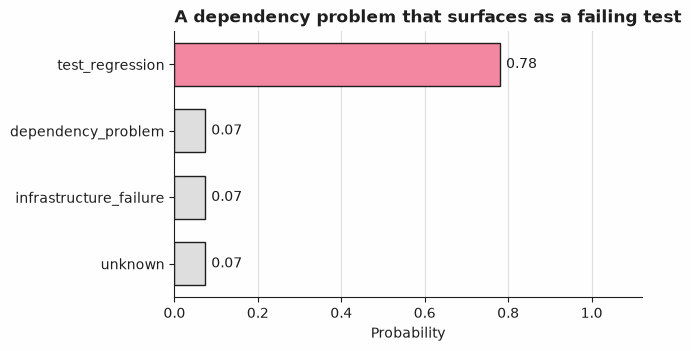

In [5]:
surfaces_example = demo["demo-01-dep-surfaces"]
surfaces_answer = decide(surfaces_example)
print(surfaces_example.fields["full_log"])
show_answer(surfaces_answer)
plot_answer_probabilities(
    surfaces_answer, title="A dependency problem that surfaces as a failing test"
)

The failing test's traceback ends in `ModuleNotFoundError: No module named 'support_sdk.v3'`: the real cause is a dependency Jev's own code never resolved, not a change in behaviour. The stored answer calls it `test_regression` anyway, at confidence 0.71. This demo build carries no gold label (demo examples are never scored), but the identical pattern recurs, scored, in `validation` and `test` below, including a confidently wrong case in each.

In [6]:
fartrim_answer = decide(fartrim)
show_answer(fartrim_answer)

Choice: dependency_problem (confidence 0.49)
  dependency_problem      0.62  ############
  test_regression         0.13  ###
  infrastructure_failure  0.13  ###
  unknown                 0.13  ###
Provenance: synthetic


This is the same `v-dep-04-fartrim` build from "The state" above. The stored answer correctly calls it `dependency_problem`, but at a lower confidence (0.49) than the surfaces example above (0.71): this fixture's probabilities were written with more weight left on the other three outcomes, to model a build whose excerpt carries two decisive-looking windows rather than one clean signal. Nothing here says how confident a real call would actually be; only this stored number is real.

In [7]:
flaky_example = demo["demo-02-unknown-flaky"]
flaky_answer = decide(flaky_example)
print(flaky_example.fields["full_log"])
show_answer(flaky_answer)

$ pytest -q
============================= test session starts ==============================
collected 140 items
tests/ ................................

=================================== FAILURES ====================================
____________________________ tests/test_notification_batch.py::test_batch_dedup ____________________________
E   AssertionError: assert False == True
FAILED tests/test_notification_batch.py::test_batch_dedup - AssertionError (flaky: passed on rerun 1/1)
139 passed, 1 flaky test rerun and passed in 33.04s
Choice: unknown (confidence 0.47)
  unknown                 0.60  ############
  test_regression         0.13  ###
  dependency_problem      0.13  ###
  infrastructure_failure  0.13  ###
Provenance: synthetic


The test failed once and passed on an automatic rerun, with nothing else in the log pointing at a cause. The stored answer calls this `unknown` at confidence 0.47. `classify` below delivers `unknown` as a final result whatever its confidence, because `manual_triage`, the workflow Python logs for it, commits to no automated remedy (CONTRIBUTING.md, section 4): there is nothing a confidence gate would be protecting here.

In [8]:
contrast_example = examples_by_id["v-tr-01"]
contrast_answer = decide(contrast_example)
show_answer(contrast_answer)

Choice: test_regression (confidence 0.84)
  test_regression         0.88  ##################
  dependency_problem      0.04  #
  infrastructure_failure  0.04  #
  unknown                 0.04  #
Provenance: synthetic


A clean, confident case for contrast: a genuine assertion failure, nothing ambiguous about it, at confidence 0.84. Whether that clears the bar below depends on the threshold "Python's part" chooses next.

## Python's part

Jev supplies the judgment; what happens with it is code. `helpers.WORKFLOWS` is the fixed table the build notes ask for, keyed by outcome: `test_regression` to `rerun_suite_with_bisect`, `dependency_problem` to `pin_and_rebuild_dependencies`, `infrastructure_failure` to `requeue_on_fresh_runner`, `unknown` to `manual_triage`. `classify` in `helpers.py` logs the table's workflow to a simulated `ActionLog`, which never executes anything, only when the answer names a workflow Python recognises *and* is confident enough; otherwise it goes to a `ReviewQueue` instead, with the reason recorded. `unknown` is the one exception: it is always delivered with its workflow logged, never reviewed, whatever its confidence. The three substantive outcomes each name an automated remedy a real system would act on, so Python gates them before logging that it would act; `manual_triage` commits to no automated remedy at all, so there is nothing left for a gate to protect (CONTRIBUTING.md, section 4). `tests/test_helpers.py` checks this at the boundary for every one of the three gated outcomes, and for `unknown` at the lowest confidence a `Choice` answer naming it can have.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate on the 19 `validation` builds. Applying that frozen threshold to the four answers shown above produces every outcome the rule can return.

In [9]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

demo_actions, demo_queue = ActionLog(), ReviewQueue()
for shown_id, shown_example, shown_answer in (
    ("demo-01-dep-surfaces", surfaces_example, surfaces_answer),
    ("v-dep-04-fartrim", fartrim, fartrim_answer),
    ("demo-02-unknown-flaky", flaky_example, flaky_answer),
    ("v-tr-01", contrast_example, contrast_answer),
):
    diagnosis = helpers.classify(
        shown_example.fields["build_id"],
        shown_answer,
        threshold,
        actions=demo_actions,
        queue=demo_queue,
    )
    workflow = f" ({diagnosis.workflow})" if diagnosis.workflow else ""
    print(
        f"{shown_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {diagnosis.outcome}{workflow} [{diagnosis.reason}]"
    )

chosen threshold, frozen from here on: 0.8400 (a selection step, not a reported result) (a pipeline check, not a Jev result)
demo-01-dep-surfaces: test_regression at confidence 0.71 -> review [confidence below the threshold]
v-dep-04-fartrim: dependency_problem at confidence 0.49 -> review [confidence below the threshold]
demo-02-unknown-flaky: unknown at confidence 0.47 -> unknown (manual_triage) [no option fits]
v-tr-01: test_regression at confidence 0.84 -> test_regression (rerun_suite_with_bisect) [confident match]


## Evaluation

The threshold was chosen and frozen above, on `validation`. `classify` sends `unknown` straight through regardless of confidence, so its accept/review split is not a pure confidence gate: `evaluate_selective`, which only ever compares a confidence against a threshold, can disagree with `classify` about which builds were answered the moment an `unknown` call sits on either side of the threshold. This evaluation therefore reports coverage, accuracy and risk from `classify`'s own outcomes with `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` (docs/evaluation.md), where `accepted[i]` is whether `classify` answered build `i` directly (its outcome is not `review`) and `correct[i]` is whether that answer matched the gold label: `coverage` is the fraction of builds answered directly, and among those, `accuracy` is the fraction right and `risk` is its complement, `1 - accuracy`. A later cell computes `evaluate_selective` on the same `test` split too, so the claim that the two can disagree is shown as numbers, not only argued. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice and a confusion matrix against the gold labels over all four outcomes, and the `unknown`/`review` counts on their own. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step *and* a pipeline check, which is why it carries both labels.

In [10]:
def diagnose_split(split_examples, split_answers, split_gold, threshold):
    """Apply classify to every answer in a split and tally what it actually returned."""
    actions, queue = ActionLog(), ReviewQueue()
    diagnoses = [
        helpers.classify(e.fields["build_id"], a, threshold, actions=actions, queue=queue)
        for e, a in zip(split_examples, split_answers, strict=True)
    ]
    accepted = [d.outcome != helpers.REVIEW for d in diagnoses]
    correct = [d.outcome == g for d, g in zip(diagnoses, split_gold, strict=True)]
    return diagnoses, accepted, correct, actions, queue


val_diagnoses, val_accepted, val_correct_rule, val_actions, val_queue = diagnose_split(
    val_examples, val_answers, val_gold, threshold
)
val_selective = evaluate_outcomes(val_accepted, val_correct_rule)
val_unknown = sum(1 for d in val_diagnoses if d.outcome == "unknown")
val_review = sum(1 for d in val_diagnoses if d.outcome == helpers.REVIEW)

print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the raw choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(f"unknown (final, no gate): {val_unknown} of {len(val_examples)}{selection}{check}")
print(f"review: {val_review} of {len(val_examples)}{selection}{check}")
print(
    f"answered by the rule: {val_selective.n_answered} of {val_selective.n_total} "
    f"(coverage {val_selective.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_selective.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_selective.risk:.4f}{selection}{check}")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a selection step, not a reported result) (a pipeline check, not a Jev result)
unknown (final, no gate): 4 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
review: 14 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
answered by the rule: 5 of 19 (coverage 0.2632) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)


test, 19 examples, threshold 0.8400 frozen (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a pipeline check, not a Jev result)
unknown (final, no gate): 5 of 19 (a pipeline check, not a Jev result)
review: 13 of 19 (a pipeline check, not a Jev result)
answered by the rule: 6 of 19 (coverage 0.3158) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8333 (a pipeline check, not a Jev result)
risk among those answered: 0.1667 (a pipeline check, not a Jev result)
confusion matrix, gold (rows) by predicted (columns) (a pipeline check, not a Jev result)
                                   test_regression        dependency_problem    infrastructure_failure                   unknown
test_regression                                  4                         0                         0                         1
dependency_problem                               1                         4                         0                         0
infrastructure_

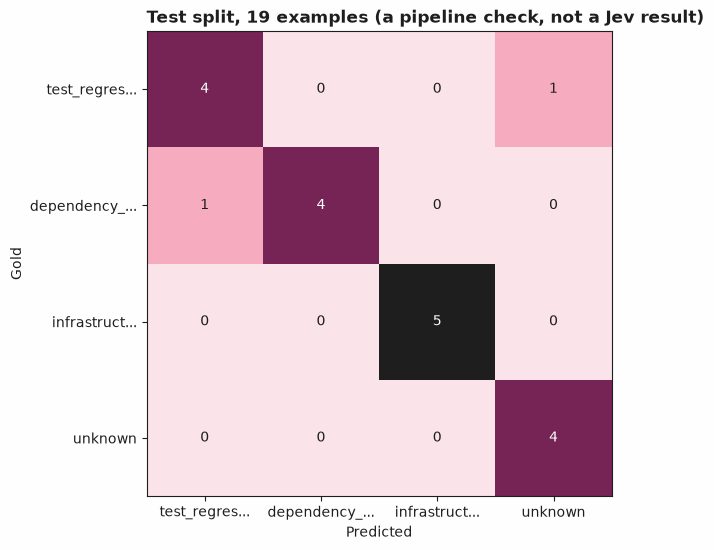

In [11]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_diagnoses, test_accepted, test_correct_rule, test_actions, test_queue = diagnose_split(
    test_examples, test_answers, test_gold, threshold
)
test_selective = evaluate_outcomes(test_accepted, test_correct_rule)
test_unknown = sum(1 for d in test_diagnoses if d.outcome == "unknown")
test_review = sum(1 for d in test_diagnoses if d.outcome == helpers.REVIEW)

print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the raw choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"unknown (final, no gate): {test_unknown} of {len(test_examples)}{check}")
print(f"review: {test_review} of {len(test_examples)}{check}")
print(
    f"answered by the rule: {test_selective.n_answered} of {test_selective.n_total} "
    f"(coverage {test_selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_selective.accuracy:.4f}{check}")
print(f"risk among those answered: {test_selective.risk:.4f}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OUTCOMES))
print(f"confusion matrix, gold (rows) by predicted (columns){check}")
header = "".join(f"{name:>26s}" for name in matrix.labels)
print(f"{'':24s}{header}")
for gold_name, row in zip(matrix.labels, matrix.matrix, strict=True):
    cells_text = "".join(f"{v:>26d}" for v in row)
    print(f"{gold_name:24s}{cells_text}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Both of `test`'s two raw mistakes are the hard cases this use case names, on purpose: the dependency problem that surfaces as a failing test (`t-dep-02-surfaces`) is called `test_regression`, and the one build whose gold label is `test_regression` but whose stored answer confidently calls it `unknown` (`t-tr-05-wrong`) lands in the `unknown` column instead. Nothing else is misclassified; `infrastructure_failure` has no errors at all on this split, including its own hard case, the runner lost mid-test.

Two baselines without any typed answer at all, for scale. The first is as trivial as a baseline can be: predict whatever outcome is most common on `validation`, for every `test` build, regardless of its log. The second uses the same keyword patterns `trim_log` already scans for (`helpers.DEPENDENCY_RE`, `helpers.INFRASTRUCTURE_RE`, `helpers.FAILURE_RE`), checked in that order against the *untrimmed* log, with no judgment about how the signals interact and no excerpt at all.

In [12]:
from collections import Counter

majority_label, _ = Counter(val_gold).most_common(1)[0]
majority_accuracy = accuracy(test_gold, [majority_label] * len(test_gold))


def keyword_baseline(full_log):
    if helpers.DEPENDENCY_RE.search(full_log):
        return helpers.DEPENDENCY_PROBLEM
    if helpers.INFRASTRUCTURE_RE.search(full_log):
        return helpers.INFRASTRUCTURE_FAILURE
    if helpers.FAILURE_RE.search(full_log):
        return helpers.TEST_REGRESSION
    return helpers.UNKNOWN


keyword_predictions = [keyword_baseline(e.fields["full_log"]) for e in test_examples]
keyword_accuracy = accuracy(test_gold, keyword_predictions)
raw_accuracy = accuracy(test_gold, test_answers)

print(
    f"majority-class baseline ('{majority_label}' for every build): {majority_accuracy:.4f}{check}"
)
print(f"keyword-regex baseline (no excerpt, no judgment): {keyword_accuracy:.4f}{check}")
print(f"raw choice accuracy on the same split: {raw_accuracy:.4f}{check}")

majority-class baseline ('test_regression' for every build): 0.2632 (a pipeline check, not a Jev result)
keyword-regex baseline (no excerpt, no judgment): 0.8421 (a pipeline check, not a Jev result)
raw choice accuracy on the same split: 0.8947 (a pipeline check, not a Jev result)


The raw choice clearly beats the majority-class baseline, 0.89 against 0.26: predicting `test_regression` for everything only happens to be right on the `test_regression` builds. It also beats the keyword baseline, by exactly one build out of nineteen, and the comparison is worth looking at closely rather than waving away: the keyword rule's priority order reads every `FAILED`/`AssertionError` line as `test_regression` once no dependency or infrastructure pattern matches, which is wrong for three of this split's four flaky `unknown` builds, each of which carries exactly that pattern in its own flaky-but-resolved line. The stored answers get all three of those right where the keyword rule does not. The keyword rule, in turn, gets both of this split's confidently wrong hard cases right where the stored answers do not: it reads `t-dep-02-surfaces`'s traceback correctly as `dependency_problem`, and `t-tr-05-wrong`'s plain assertion correctly as `test_regression`, neither fooled the way the stored probabilities were written to be. Three gained against two lost on nineteen builds is where the one-build margin above comes from; it is a property of this fixture set, not a claim about Jev, and a larger or more varied log set could easily move it either way.

For each outcome, `precision` is the fraction of the raw choice's calls of that outcome that were actually right, and `recall` is the fraction of that outcome's real `test` builds the raw choice found at all; `f1` is their harmonic mean, and `support` is how many `test` builds actually carry that gold label.

In [13]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OUTCOMES))
for outcome, counts in per_class.items():
    print(
        f"{outcome:24s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

test_regression          precision 0.800  recall 0.800  f1 0.800  support 5 (a pipeline check, not a Jev result)
dependency_problem       precision 1.000  recall 0.800  f1 0.889  support 5 (a pipeline check, not a Jev result)
infrastructure_failure   precision 1.000  recall 1.000  f1 1.000  support 5 (a pipeline check, not a Jev result)
unknown                  precision 0.800  recall 1.000  f1 0.889  support 4 (a pipeline check, not a Jev result)


In [14]:
# The claim in "Evaluation" above, made concrete: evaluate_selective reapplies confidence >=
# threshold to the raw choice, with no knowledge of `classify`'s unconditional `unknown` branch.
test_raw_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
test_selective_by_confidence = evaluate_selective(test_raw_correct, test_confidence, threshold)

print(f"evaluate_outcomes (classify's own accept/review split){check}")
print(
    f"  answered {test_selective.n_answered} of {test_selective.n_total}, coverage "
    f"{test_selective.coverage:.4f}, accuracy {test_selective.accuracy:.4f}, risk "
    f"{test_selective.risk:.4f}{check}"
)
print(f"evaluate_selective (confidence >= {threshold:.4f} alone){check}")
print(
    f"  answered {test_selective_by_confidence.n_answered} of {test_selective_by_confidence.n_total}, "
    f"coverage {test_selective_by_confidence.coverage:.4f}, accuracy "
    f"{test_selective_by_confidence.accuracy:.4f}, risk {test_selective_by_confidence.risk:.4f}{check}"
)

evaluate_outcomes (classify's own accept/review split) (a pipeline check, not a Jev result)
  answered 6 of 19, coverage 0.3158, accuracy 0.8333, risk 0.1667 (a pipeline check, not a Jev result)
evaluate_selective (confidence >= 0.8400 alone) (a pipeline check, not a Jev result)
  answered 1 of 19, coverage 0.0526, accuracy 1.0000, risk 0.0000 (a pipeline check, not a Jev result)


The two disagree sharply, not only in principle: `evaluate_selective` alone would answer just one build of nineteen (coverage 0.0526, the one confident, correct `test_regression` call whose confidence clears 0.84), because it is blind to every `unknown` call, confident or not. `classify` answers six, because every `unknown` call is delivered on its own terms. That gap is also where `risk` above comes from, and the reason is structural, not a near-miss of the confidence gate: the build whose gold label is `test_regression` but whose stored answer confidently calls it `unknown` (`t-tr-05-wrong`, confidence 0.80) is accepted by `classify` regardless of the threshold, because `unknown` never checks confidence at all; raising the threshold to 1.0 would not catch it. The other raw mistake, the dependency problem that surfaces as a failing test (`t-dep-02-surfaces`, also confidence 0.80), *is* caught: 0.80 sits below the 0.84 threshold frozen on `validation`, so `classify` sends it to review instead of logging `rerun_suite_with_bisect` on the strength of a wrong guess. The confidence gate is doing real work here; it simply cannot reach a call that never goes through it.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored builds (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose, including two wrong *and* confident in different ways, one caught by the confidence gate and one not, so every number above describes this fixture set and not a model.

In [15]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard log to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- Change `target_accuracy` in the evaluation cell to something looser than `1.0` and see how coverage and the review count trade off.
- Gate `unknown` the same way the other three outcomes are gated (drop the early return in `classify`) and see whether `t-tr-05-wrong` above is still accepted.
- Neighbouring recipes: [`18-duplicate-incident-matching`](../18-duplicate-incident-matching/) and [`20-claim-support-classification`](../20-claim-support-classification/), both `Choice` recipes like this one.